# Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [15]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.utils.catalog_tests as catalog_tests
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import visualize_sequence
from src.utils.bootstrap_ci import bootstrap_multi_model_metric_ci, SamplingMethod
from src.utils.bootstrap_presets import PairedBootstrapPreset

set_seed(0)
np.random.seed(0)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration (Multi-model)

In [16]:
# Add any number of checkpoints here for comparison.
# label: display name in tables/plots
MODEL_SPECS = [
    {
        'label': 'Mixer-TPP',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints/mixer_tpp_20260206-102040/best_model_1.pth',
        'compile': True,
        'override_M_m': 10.0,
    },
    {
        'label': 'recast',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints/rtpp_20260506-173356/best_model_1.pth',
        'compile': True,
        'override_M_m': 10.0,
    },
]

for spec in MODEL_SPECS:
    print(f"[{spec['label']}] {spec['checkpoint_path']}")


[Mixer-TPP] /root/autodl-tmp/em_eqf/checkpoints/mixer_tpp_20260206-102040/best_model_1.pth
[recast] /root/autodl-tmp/em_eqf/checkpoints/rtpp_20260506-173356/best_model_1.pth


## 3) Load Trained Models

In [17]:
loaded_models = []
base_args = None

for spec in MODEL_SPECS:
    ckpt_path = spec['checkpoint_path']
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model_i, args_i = load_and_prepare_model(
        checkpoint_path=ckpt_path,
        device=DEVICE,
        compile=bool(spec.get('compile', True)),
    )

    override_mm = spec.get('override_M_m', None)
    if override_mm is not None and hasattr(model_i, 'M_m'):
        model_i.M_m = torch.tensor(float(override_mm), device=DEVICE)

    loaded_models.append(
        {
            'label': spec['label'],
            'checkpoint_path': ckpt_path,
            'model': model_i,
            'args': args_i,
        }
    )

    if base_args is None:
        base_args = args_i
    elif args_i.dataset != base_args.dataset:
        raise ValueError(
            f"All models must use the same dataset for paired bootstrap. "
            f"Got {base_args.dataset} vs {args_i.dataset}."
        )

for item in loaded_models:
    print(f"Loaded: {item['label']} | model={item['args'].model} | dataset={item['args'].dataset}")


Loaded: Mixer-TPP | model=mixer_tpp | dataset=ChuanDian
Loaded: recast | model=rtpp | dataset=ChuanDian


## 4) Load Catalog and Visualize

Using catalog registry name: ChuanDian-Standard


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

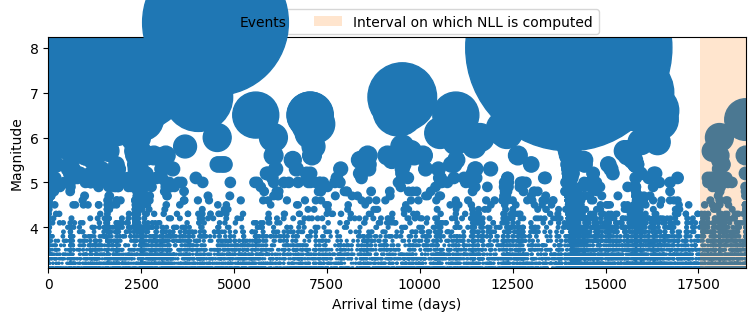

In [18]:
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    base_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / base_args.dataset,
    catalog_cfg=getattr(base_args, 'catalog_cfg', {}),
)
print(f'Using catalog registry name: {registry_name}')

train_seq = catalog_ds.train[0]
test_seq = catalog_ds.test[0]

visualize_sequence(test_seq, show_nll=True)


In [19]:
import src.utils.catalog_utils as catalog_utils

# Split test_seq using unlimited max_events so each window keeps original start.
test_seq_splits = catalog_utils.split_sequence(
    test_seq,
    mean_batch_size=getattr(base_args, 'mean_nll_events', 30),
    max_events=None,
)
print(f"Split test_seq into {len(test_seq_splits)} windows")
print(
    f"First split: t_start={test_seq_splits[0].t_start}, "
    f"t_nll_start={test_seq_splits[0].t_nll_start}, "
    f"num_events={test_seq_splits[0].num_events}"
)


Split test_seq into 35 windows
First split: t_start=0.0, t_nll_start=17532.0, num_events=10545


In [20]:
test_seq_splits

TppDataset(35)

## 5) Test Window Likelihood + Paired Bootstrap


In [21]:
from src.data import Batch

# Keep evaluation aligned with main.py test branch.
TEST_NLL_REDUCTION = getattr(base_args, 'loss_reduction', None)

BOOTSTRAP_SAMPLING_METHOD: SamplingMethod = 'block'  # 'iid' or 'block'
BOOTSTRAP_PRESET = PairedBootstrapPreset(
    sampling=BOOTSTRAP_SAMPLING_METHOD,
    ci=(2.5, 97.5),
    n_resamples_curve=400,
    n_resamples_metric=2000,
    block_size=max(1, int(round(np.sqrt(len(test_seq_splits))))),
    circular_block=True,
)

print(f'TEST_NLL_REDUCTION: {TEST_NLL_REDUCTION}')
print(f'BOOTSTRAP sampling={BOOTSTRAP_PRESET.sampling}, metric_resamples={BOOTSTRAP_PRESET.n_resamples_metric}, block_size={BOOTSTRAP_PRESET.block_size}')


TEST_NLL_REDUCTION: per_time
BOOTSTRAP sampling=block, metric_resamples=2000, block_size=6


In [22]:
def _model_nll_on_sequence(model_obj, seq, *, reduction=None):
    batch = Batch.from_list([seq]).to(DEVICE)

    nll_kwargs = {}
    if reduction is not None:
        nll_kwargs['reduction'] = reduction

    out = model_obj.nll_loss(batch, **nll_kwargs)

    if isinstance(out, dict):
        time_val = out.get('time', out.get('total'))
        total_val = out.get('total', time_val)
    else:
        time_val = out
        total_val = out

    return {
        'time': torch.as_tensor(time_val).detach().cpu().reshape(-1),
        'total': torch.as_tensor(total_val).detach().cpu().reshape(-1),
    }


window_rows = []
for i, seq in enumerate(test_seq_splits):
    base_row = {
        'window_idx': i,
        't_start': float(seq.t_start),
        't_nll_start': float(seq.t_nll_start),
        't_end': float(seq.t_end),
        'num_events': int(seq.num_events),
        'window_duration': float(seq.t_end - seq.t_start),
    }
    for item in loaded_models:
        out = _model_nll_on_sequence(item['model'], seq, reduction=TEST_NLL_REDUCTION)
        row = dict(base_row)
        row['label'] = item['label']
        for key, value in out.items():
            row[f'nll_{key}'] = float(value.mean().item())
        window_rows.append(row)

window_df = pd.DataFrame(window_rows)
if window_df.empty:
    raise ValueError('No test subwindows were generated.')

print(window_df[['label', 'window_idx', 'num_events', 'nll_time', 'nll_total']].head())
print('models:', sorted(window_df['label'].unique().tolist()))
print('windows per model:')
print(window_df.groupby('label')['window_idx'].nunique())



       label  window_idx  num_events  nll_time  nll_total
0  Mixer-TPP           0       10545  0.577210   0.576406
1     recast           0       10545  0.572027   0.572027
2  Mixer-TPP           1       10564  0.925577   1.096284
3     recast           1       10564  0.957235   0.957235
4  Mixer-TPP           2       10586  0.925767   1.167049
models: ['Mixer-TPP', 'recast']
windows per model:
label
Mixer-TPP    35
recast       35
Name: window_idx, dtype: int64


In [23]:
# Build paired matrix: each row is a subwindow, each column is a model.
model_labels = [item['label'] for item in loaded_models]
BOOTSTRAP_BASELINE_MODEL = None  # None => use first model label
effective_baseline_model = BOOTSTRAP_BASELINE_MODEL or (model_labels[0] if len(model_labels) > 0 else None)

pivot_total = (
    window_df.pivot_table(index='window_idx', columns='label', values='nll_total', aggfunc='first')
    .reindex(columns=model_labels)
    .sort_index()
)

if pivot_total.isna().any().any():
    missing = int(pivot_total.isna().sum().sum())
    raise ValueError(f'Paired bootstrap requires complete aligned windows. Missing cells: {missing}')

y_true_dummy = np.zeros(len(pivot_total), dtype=np.int64)
model_predictions = {label: pivot_total[label].to_numpy(dtype=float) for label in model_labels}

bootstrap_kwargs = {
    'y_true': y_true_dummy,
    'model_predictions': model_predictions,
    'metric': lambda y_true, y_pred: float(np.mean(y_pred)),
    'task': 'regression',
    'config': BOOTSTRAP_PRESET.metric_config(seed=123),
}
if len(model_labels) >= 3:
    if effective_baseline_model is None:
        raise ValueError('No baseline model available for >=3 models.')
    bootstrap_kwargs['baseline_model'] = effective_baseline_model

paired_result = bootstrap_multi_model_metric_ci(**bootstrap_kwargs)

summary_rows = []
for label in model_labels:
    r = paired_result.model_results[label]
    summary_rows.append(
        {
            'label': label,
            'point_estimate': r.point_estimate,
            'ci_low': r.ci_low,
            'ci_high': r.ci_high,
            'valid_resamples': r.valid_resamples,
            'total_resamples': r.total_resamples,
        }
    )

paired_bootstrap_summary = pd.DataFrame(summary_rows)
print('--- Paired bootstrap: window-mean nll_total ---')
if len(model_labels) >= 3:
    print(f'Paired bootstrap baseline: {effective_baseline_model}')
print(paired_bootstrap_summary.to_string(index=False))

if len(model_labels) >= 2:
    delta_rows = []
    for (left, right), r in paired_result.pairwise_deltas.items():
        delta_rows.append(
            {
                'left_model': left,
                'right_model': right,
                'delta_name': f'{left} - {right}',
                'delta_point_estimate': r.point_estimate,
                'ci_low': r.ci_low,
                'ci_high': r.ci_high,
                'valid_resamples': r.valid_resamples,
                'total_resamples': r.total_resamples,
            }
        )
    paired_delta_summary = pd.DataFrame(delta_rows)
    print('\n--- Paired bootstrap deltas ---')
    print(paired_delta_summary.to_string(index=False))
else:
    paired_delta_summary = pd.DataFrame()
    print('Only one model loaded; skipping pairwise delta table.')


--- Paired bootstrap: window-mean nll_total ---
    label  point_estimate   ci_low  ci_high  valid_resamples  total_resamples
Mixer-TPP        0.857347 0.577266 1.101556             2000             2000
   recast        0.561357 0.188453 0.906042             2000             2000

--- Paired bootstrap deltas ---
left_model right_model         delta_name  delta_point_estimate  ci_low  ci_high  valid_resamples  total_resamples
 Mixer-TPP      recast Mixer-TPP - recast               0.29599 0.17557 0.443575             2000             2000


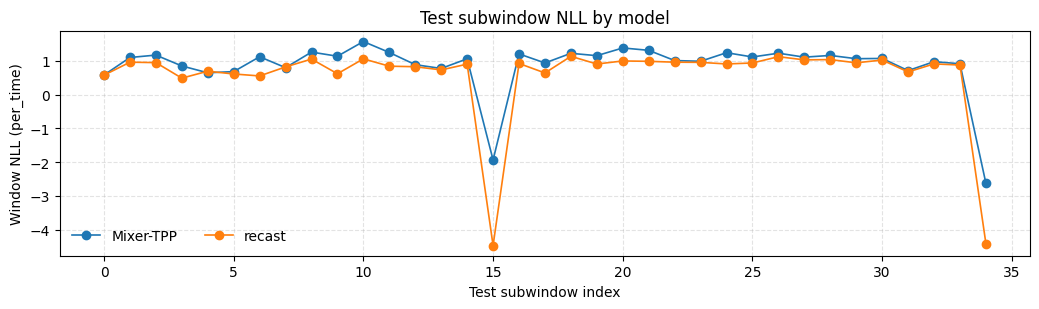

In [24]:
# Optional: visualize per-window nll_total for all models.
fig, ax = plt.subplots(figsize=(10.5, 3.2))
for label in model_labels:
    sub = window_df[window_df['label'] == label].sort_values('window_idx')
    ax.plot(sub['window_idx'], sub['nll_total'], marker='o', linewidth=1.2, label=label)

ax.set_xlabel('Test subwindow index')
ax.set_ylabel(f'Window NLL ({TEST_NLL_REDUCTION})')
ax.set_title('Test subwindow NLL by model')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(frameon=False, ncol=min(3, max(1, len(model_labels))))
plt.tight_layout()
plt.show()
